In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

In [4]:
#1 if Cabin is present, 0 if NaN

df['hascabin'] = df['Cabin'].notna().astype(int)

In [5]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\mabdu\AppData\Local\Temp\ipykernel_17468\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [6]:
df.head()

,ivPassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hascabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [7]:
df = df.drop('Name',axis =1)
df = df.drop('ivPassengerId',axis =1)

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hascabin
0,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,1,1,female,35.0,1,0,113803,53.1000,C123,S,1
4,0,3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [9]:
sex_encoder = LabelEncoder()
df['Sex'] = sex_encoder.fit_transform(df['Sex'])

In [10]:
cabin_encoder = LabelEncoder()
df['Cabin'] = cabin_encoder.fit_transform(df['Cabin'])

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,hascabin
0,0,3,1,22.0,1,0,A/5 21171,7.2500,147,S,0
1,1,1,0,38.0,1,0,PC 17599,71.2833,81,C,1
2,1,3,0,26.0,0,0,STON/O2. 3101282,7.9250,147,S,0
3,1,1,0,35.0,1,0,113803,53.1000,55,S,1
4,0,3,1,35.0,0,0,373450,8.0500,147,S,0


In [12]:
df = df.drop('Ticket',axis =1)

In [13]:
embarked_encoder = LabelEncoder()
df['Embarked'] = embarked_encoder.fit_transform(df['Embarked'])

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,hascabin
0,0,3,1,22.0,1,0,7.2500,147,2,0
1,1,1,0,38.0,1,0,71.2833,81,0,1
2,1,3,0,26.0,0,0,7.9250,147,2,0
3,1,1,0,35.0,1,0,53.1000,55,2,1
4,0,3,1,35.0,0,0,8.0500,147,2,0


In [15]:
x = df.drop(['Survived'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked  hascabin
0         3    1  22.0      1      0   7.2500    147         2         0
1         1    0  38.0      1      0  71.2833     81         0         1
2         3    0  26.0      0      0   7.9250    147         2         0
3         1    0  35.0      1      0  53.1000     55         2         1
4         3    1  35.0      0      0   8.0500    147         2         0
..      ...  ...   ...    ...    ...      ...    ...       ...       ...
886       2    1  27.0      0      0  13.0000    147         2         0
887       1    0  19.0      0      0  30.0000     30         2         1
888       3    0  28.0      1      2  23.4500    147         2         0
889       1    1  26.0      0      0  30.0000     60         0         1
890       3    1  32.0      0      0   7.7500    147         1         0

[891 rows x 9 columns]


In [16]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=2))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}

In [17]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [18]:

#no features dropped only encoding the string features

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8638
DecisionTree testing accuracy: 0.7989
------------------------------
KNN training accuracy: 0.8792
KNN testing accuracy: 0.8101
------------------------------
Naive-Bayes training accuracy: 0.7697
Naive-Bayes testing accuracy: 0.7486
------------------------------


Classification Report for DecisionTree:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       105
           1       0.81      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



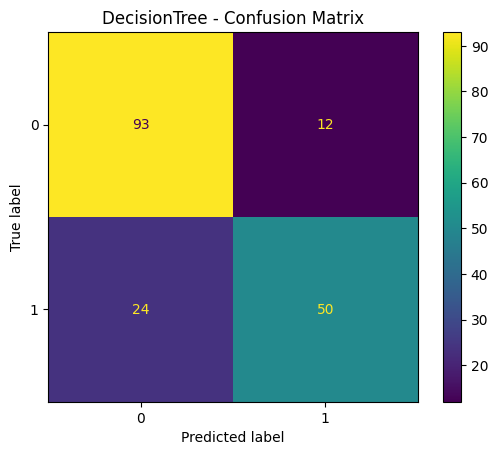

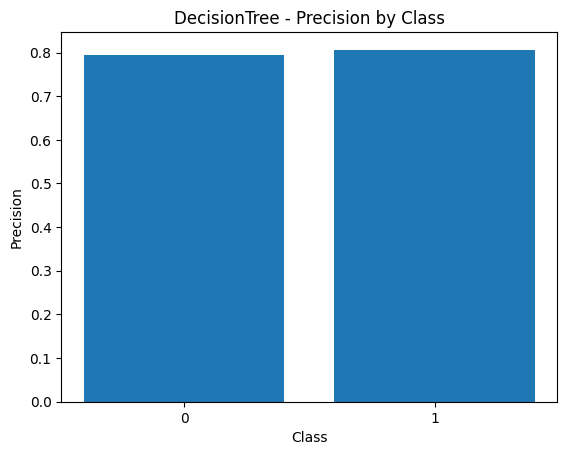

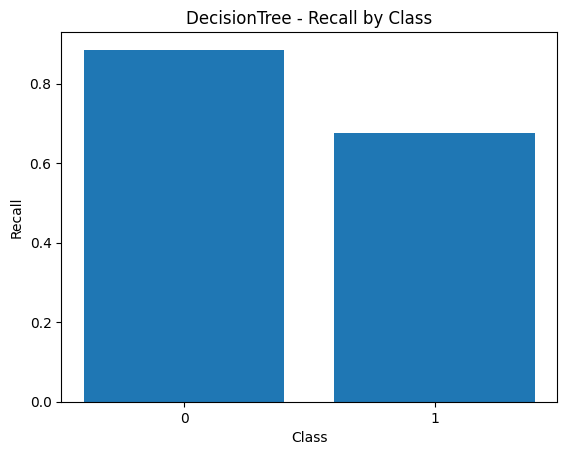

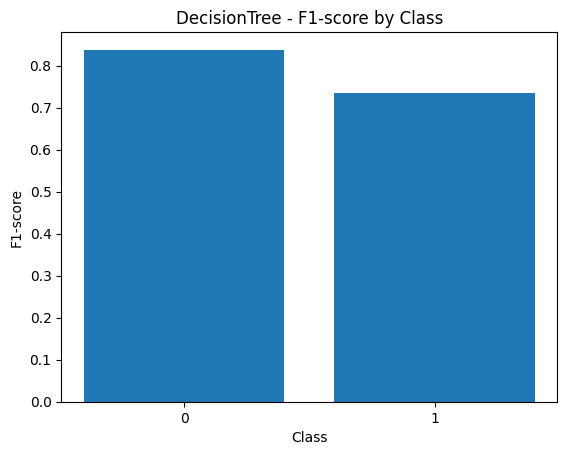

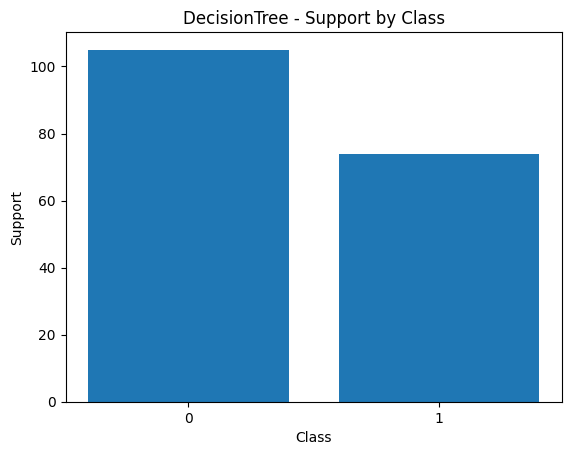

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       105
           1       0.86      0.65      0.74        74

    accuracy                           0.81       179
   macro avg       0.82      0.79      0.79       179
weighted avg       0.82      0.81      0.80       179



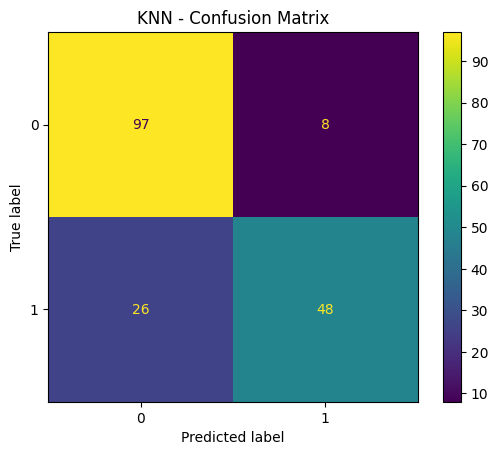

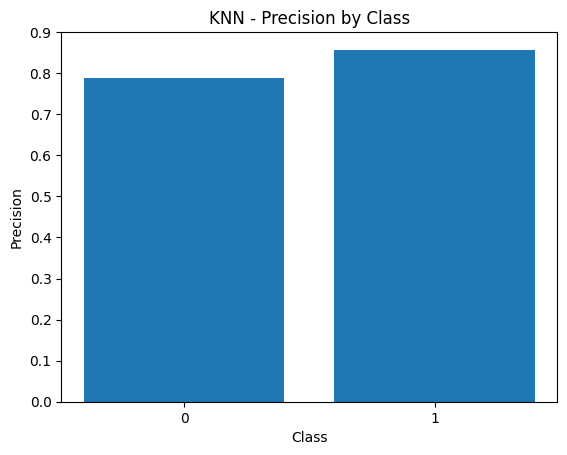

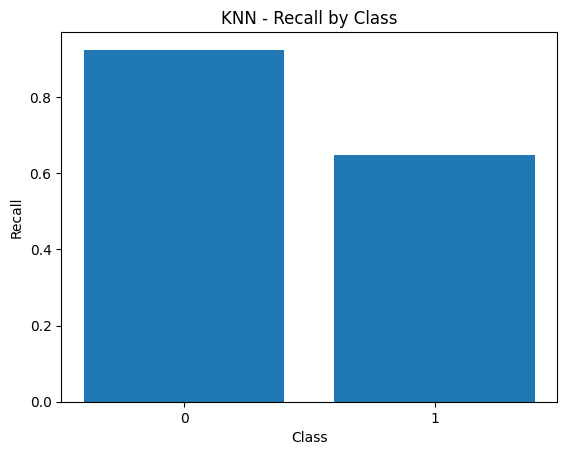

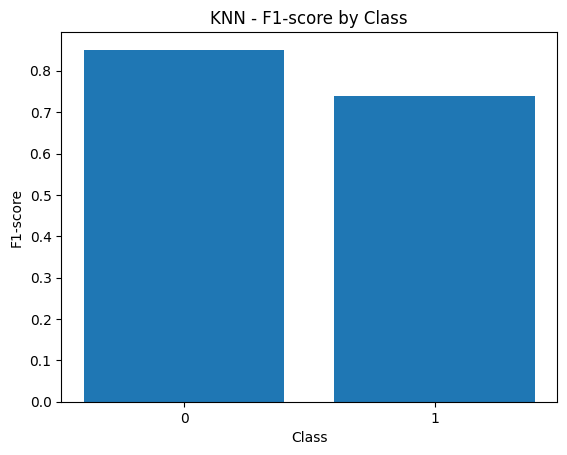

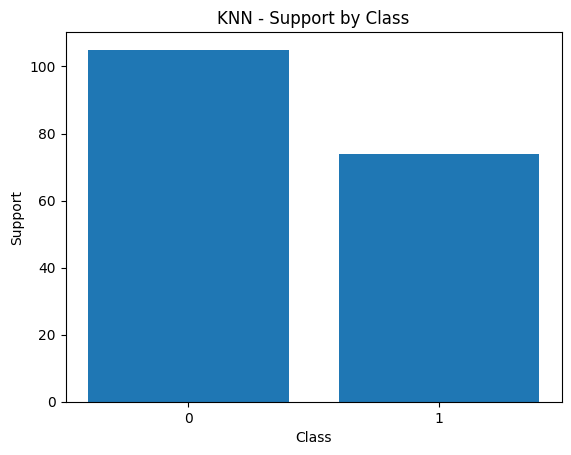

Classification Report for Naive-Bayes:
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       105
           1       0.72      0.65      0.68        74

    accuracy                           0.75       179
   macro avg       0.74      0.73      0.74       179
weighted avg       0.75      0.75      0.75       179



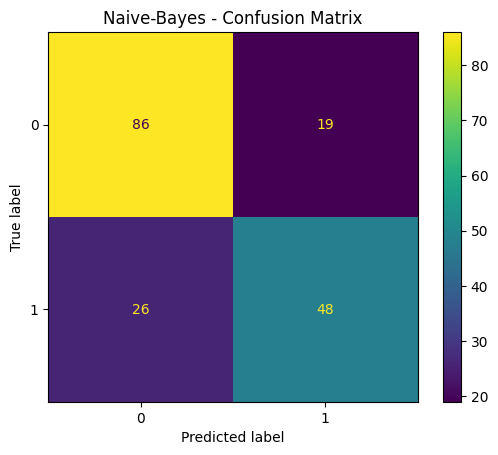

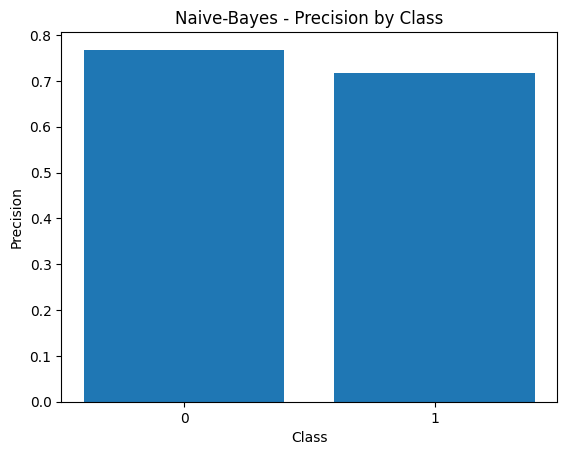

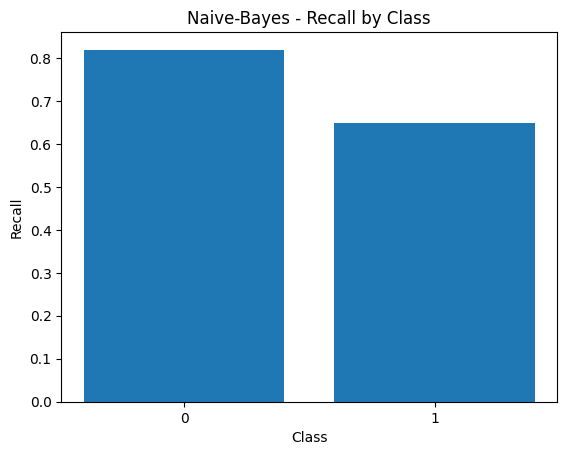

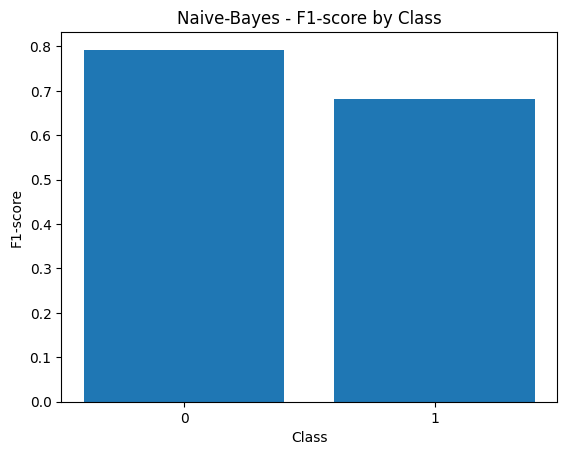

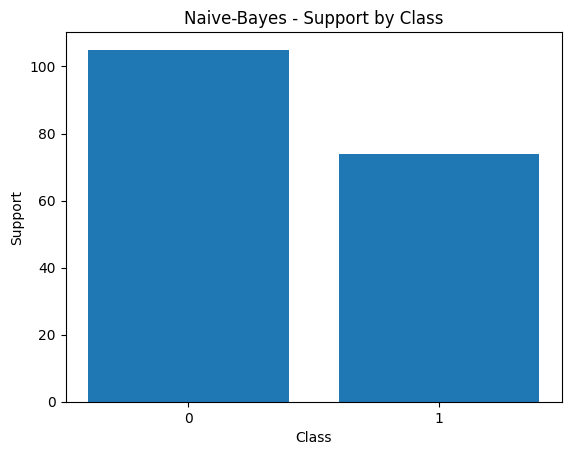

In [19]:
for name, pipe in pipelines.items():
    print(f"Classification Report for {name}:")
    y_pred = pipe.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    # Precision, Recall, F1-score, Support Bar Plots
    metrics = ['precision', 'recall', 'f1-score', 'support']
    classes = [str(label) for label in report if label in ['0', '1']]
    for metric in metrics:
        values = [report[cls][metric] for cls in classes]
        plt.bar(classes, values)
        plt.title(f"{name} - {metric.capitalize()} by Class")
        plt.xlabel("Class")
        plt.ylabel(metric.capitalize())
        plt.show()

MODEL NUMBER 2

extracting cabin deck and creating family size dropping parch, sibsp also creating an alone removing outliers 